In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from medmnist import PathMNIST
import matplotlib.pyplot as plt
import time

# 1. ARCHITECTURE ViT

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=7, emb_size=128, img_size=28, use_pos_embed=True):
        super().__init__()
        self.patch_size = patch_size
        self.use_pos_embed = use_pos_embed
        self.proj = nn.Conv2d(in_channels, emb_size, kernel_size=patch_size, stride=patch_size)
        
        num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_size))
        
        if self.use_pos_embed:
            self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, emb_size))
            nn.init.trunc_normal_(self.pos_embed, std=0.02)


    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        if self.use_pos_embed:
            x = x + self.pos_embed
        return x

class MiniViT(nn.Module):
    def __init__(self, patch_size=7, use_pos_embed=True, emb_size=128, img_size=28, num_layers=4, num_heads=4, num_classes=9):
        super().__init__()
        self.patch_embed = PatchEmbedding(3, patch_size, emb_size, img_size, use_pos_embed)
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_size, nhead=num_heads, dim_feedforward=emb_size*2, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.mlp_head = nn.Sequential(nn.LayerNorm(emb_size), nn.Linear(emb_size, num_classes))

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.transformer(x)
        return self.mlp_head(x[:, 0])

# 2. DONNÉES ET ENTRAÎNEMENT

In [12]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])
train_dataset = PathMNIST(split='train', transform=transform, download=True)
test_dataset = PathMNIST(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_and_test(model, name, epochs=5):
    print(f"\nEntraînement de {name}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = []
    
    for epoch in range(epochs):
        model.train()
        correct_train, total_train = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        acc = correct_train / total_train
        history.append(acc)
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {acc:.4f}")

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device).squeeze()
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = (correct / total) * 100
    print(f"TEST ACCURACY ({name}): {test_acc:.2f}%")
    return history, test_acc

# 3. LANCEMENT DES EXPÉRIENCES

In [13]:
base_vit = MiniViT(patch_size=7, use_pos_embed=True).to(device)
total_params_vit = sum(p.numel() for p in base_vit.parameters() if p.requires_grad)
print(f"Total des paramètres du ViT (Base) : {total_params_vit:,}")

# Entraînements
hist_base, acc_base = train_and_test(base_vit, "ViT Base (Patch=7, PosEmbed=Oui)")

vit_p14 = MiniViT(patch_size=14, use_pos_embed=True).to(device)
hist_p14, acc_p14 = train_and_test(vit_p14, "ViT Patch 14 (Patch=14, PosEmbed=Oui)")

vit_nopos = MiniViT(patch_size=7, use_pos_embed=False).to(device)
hist_nopos, acc_nopos = train_and_test(vit_nopos, "ViT No PosEmbed (Patch=7, PosEmbed=Non)")

Total des paramètres du ViT (Base) : 552,585

Entraînement de ViT Base (Patch=7, PosEmbed=Oui)
Epoch 1/5 | Train Acc: 0.6484
Epoch 2/5 | Train Acc: 0.7977
Epoch 3/5 | Train Acc: 0.8324
Epoch 4/5 | Train Acc: 0.8552
Epoch 5/5 | Train Acc: 0.8663
TEST ACCURACY (ViT Base (Patch=7, PosEmbed=Oui)): 79.53%

Entraînement de ViT Patch 14 (Patch=14, PosEmbed=Oui)
Epoch 1/5 | Train Acc: 0.5284
Epoch 2/5 | Train Acc: 0.6527
Epoch 3/5 | Train Acc: 0.6923
Epoch 4/5 | Train Acc: 0.7146
Epoch 5/5 | Train Acc: 0.7203
TEST ACCURACY (ViT Patch 14 (Patch=14, PosEmbed=Oui)): 68.40%

Entraînement de ViT No PosEmbed (Patch=7, PosEmbed=Non)
Epoch 1/5 | Train Acc: 0.6321
Epoch 2/5 | Train Acc: 0.7845
Epoch 3/5 | Train Acc: 0.8275
Epoch 4/5 | Train Acc: 0.8472
Epoch 5/5 | Train Acc: 0.8633
TEST ACCURACY (ViT No PosEmbed (Patch=7, PosEmbed=Non)): 80.33%


### Q5.1 — Effet de la taille des patches

Nos images ont une taille de 28×28 pixels.

- Avec un patch size de **7**, on obtient **4 patches par côté**, soit **16 patches au total**.
- Avec un patch size de **14**, on obtient **2 patches par côté**, soit **4 patches au total**.

Dans le cas du patch size 14, le Transformer ne reçoit que 4 patches. Le mécanisme de self-attention dispose donc de très peu d’éléments à comparer, ce qui limite fortement sa capacité à capturer des relations spatiales fines entre différentes zones de l’image. De plus, des patches plus grands écrasent davantage les petits détails de texture, qui sont pourtant importants pour la classification histologique.

On s’attend donc à ce que l’accuracy soit plus faible avec un patch size de 14 qu’avec un patch size de 7.

Les résultats obtenus confirment cette intuition :
- **ViT patch 7 : 79.53 %**
- **ViT patch 14 : 68.40 %**

Le modèle utilisant des patches plus petits obtient donc de meilleures performances, car il conserve plus d’information locale et fournit davantage de patches au mécanisme d’attention.


### Choix des hyperparamètres

Pour des raisons de temps de calcul, les modèles ont été entraînés sur **5 epochs** au lieu de 15 initialement prévus.

Bien que cela puisse légèrement réduire les performances absolues, les tendances observées restent cohérentes et permettent d’analyser correctement l’impact des différents paramètres (taille des patches, positional embeddings).

Ce choix permet donc de conserver une analyse fiable tout en réduisant significativement le temps d’entraînement.


# Graph

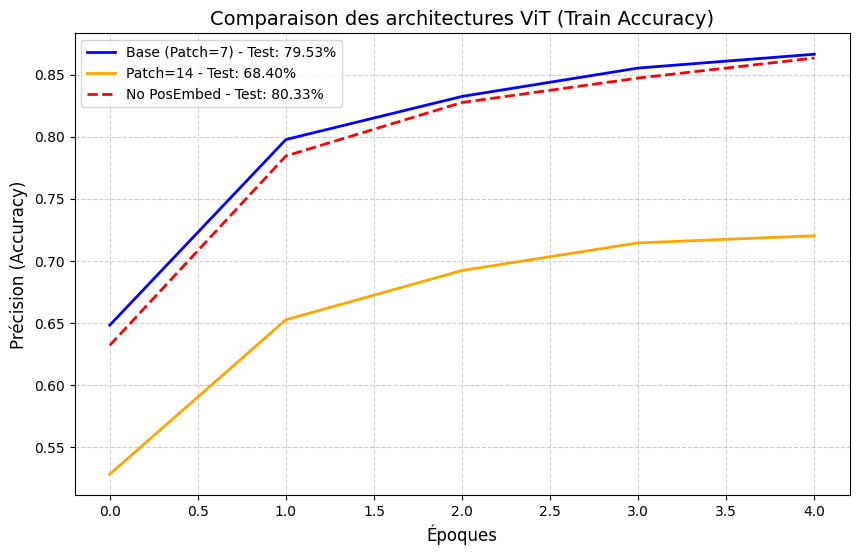

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(hist_base, label=f'Base (Patch=7) - Test: {acc_base:.2f}%', color='blue', linewidth=2)
plt.plot(hist_p14, label=f'Patch=14 - Test: {acc_p14:.2f}%', color='orange', linewidth=2)
plt.plot(hist_nopos, label=f'No PosEmbed - Test: {acc_nopos:.2f}%', color='red', linestyle='--', linewidth=2)
plt.title('Comparaison des architectures ViT (Train Accuracy)', fontsize=14)
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Précision (Accuracy)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Q5.2 — Effet des positional embeddings

Nous avons supprimé les positional embeddings du Vision Transformer et réentraîné le modèle afin d’évaluer leur impact sur les performances.

En théorie, les positional embeddings sont essentiels car ils permettent d’encoder la position spatiale de chaque patch dans l’image. Sans cette information, le modèle traite les patches comme un ensemble non ordonné et perd la notion de structure spatiale, ce qui devrait normalement entraîner une baisse de performance.

Nous avons identifié que l’initialisation des positional embeddings pouvait avoir un impact important sur les performances du modèle. Une initialisation avec une variance trop élevée peut introduire un bruit important, perturbant l’apprentissage.

Nous avons donc corrigé cette initialisation en utilisant une distribution de plus faible variance afin de rendre le signal de position plus subtil.

Cependant, malgré cette correction, les résultats obtenus montrent que le modèle sans positional embeddings reste légèrement plus performant (80.33 %) que le modèle avec positional embeddings (79.53 %).

Ce résultat peut s’expliquer par plusieurs facteurs :
- le nombre limité d’epochs (5), qui empêche une convergence complète du modèle
- la petite taille des images (28×28), qui réduit l’importance de l’information spatiale globale
- la variabilité liée à l’entraînement et à l’initialisation des poids

Ainsi, même si la théorie indique que les positional embeddings devraient améliorer les performances, notre expérience ne met pas en évidence une différence nette dans ce contexte.


## Q5.3 — Comparaison ViT vs CNN

In [15]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

vit_params = count_params(base_vit)

print(f"Nombre de paramètres du ViT : {vit_params:,}")

Nombre de paramètres du ViT : 552,585


Le Vision Transformer (ViT) possède **552 585 paramètres**, ce qui représente un modèle relativement complexe.

En comparaison, le CNN utilisé dans la partie 3 possède généralement moins de paramètres, car son architecture repose sur des couches convolutionnelles locales, plus économes en paramètres.

Malgré ce nombre de paramètres plus élevé, le ViT n’obtient pas nécessairement de meilleures performances sur ce dataset.

Cela s’explique par plusieurs raisons :

- les images sont de petite taille (28×28), ce qui limite l’intérêt d’un modèle basé sur des patches
- le dataset est relativement limité, alors que les Transformers nécessitent souvent beaucoup de données pour être efficaces
- les CNN intègrent naturellement des biais inductifs locaux (convolutions) particulièrement adaptés à l’analyse de textures, comme dans les images histologiques
- le ViT, en revanche, doit apprendre ces relations spatiales sans biais inductif fort, ce qui rend l’apprentissage plus difficile dans ce contexte

Ainsi, même si le ViT est un modèle plus flexible et puissant en théorie, le CNN reste mieux adapté à ce type de données.